In [2]:
import pandas as pd
import seaborn as sns
df=pd.read_csv('salary_data.csv')
df

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [3]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.isnull().sum()

,0
YearsExperience,0
Salary,0


<Axes: xlabel='YearsExperience', ylabel='Salary'>

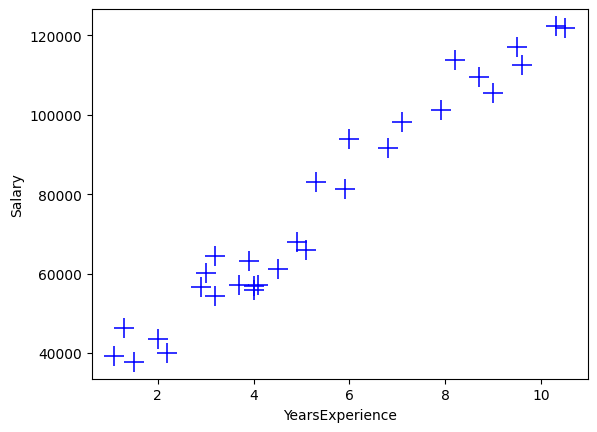

In [21]:
sns.scatterplot(x='YearsExperience',y='Salary',color='b',s=200,marker='+',data =df)

<Axes: ylabel='Salary'>

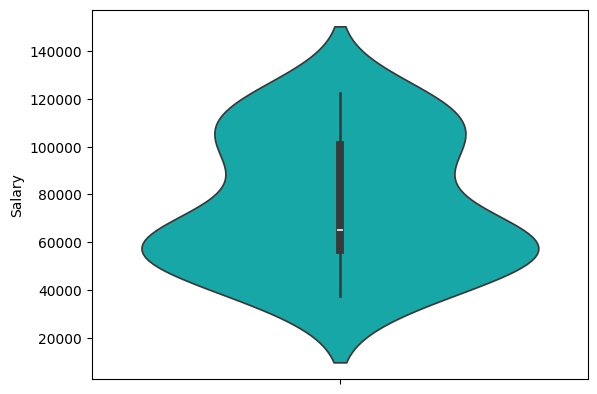

In [23]:
sns.violinplot(y=df['Salary'],color='c')

<Axes: xlabel='YearsExperience'>

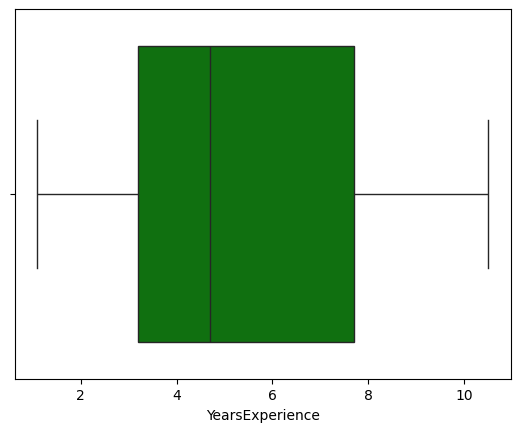

In [43]:
sns.boxplot(x='YearsExperience',data =df,color='g')

<Axes: xlabel='YearsExperience'>

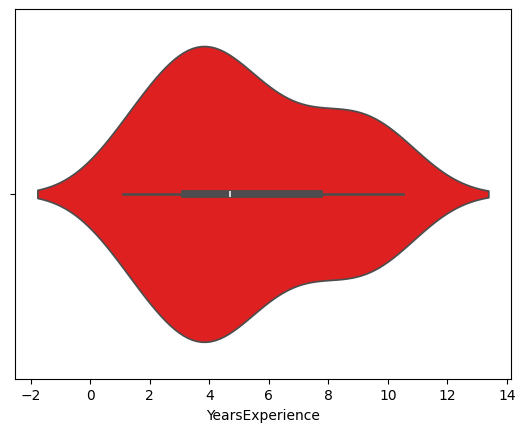

In [41]:
sns.violinplot(x=df['YearsExperience'],color='r')

<Axes: xlabel='YearsExperience', ylabel='Salary'>

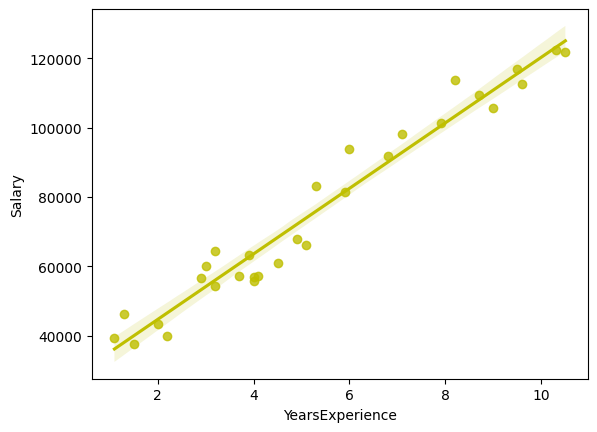

In [45]:
sns.regplot(x='YearsExperience',y='Salary',color='y',data = df)

<Axes: xlabel='Salary'>

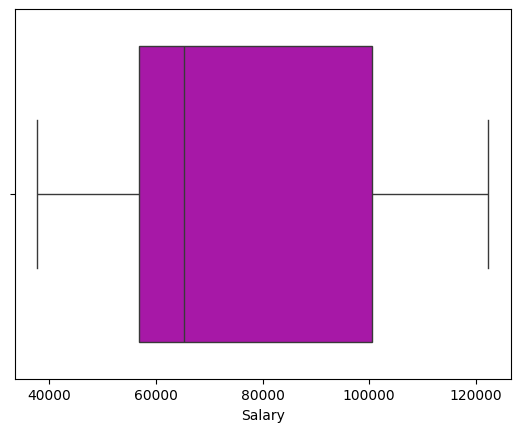

In [37]:
sns.boxplot(x='Salary',data =df,color='m')

<Axes: >

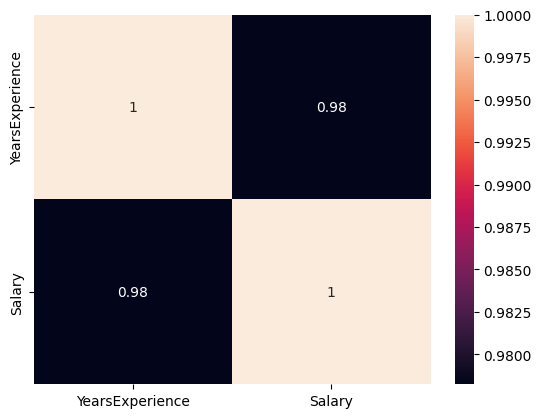

In [12]:
sns.heatmap(df.corr(),annot=True)

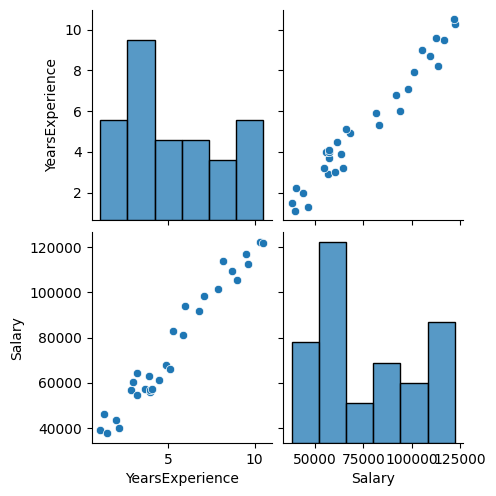

In [48]:
sns.pairplot(df[['YearsExperience','Salary']])


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import pandas as pd
X=df[['Salary']]
y=df['YearsExperience']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

regression=LinearRegression()
regression.fit(X_train, y_train)
y_pred=regression.predict(X_test)
score=r2_score(y_test,y_pred)
print(score)

0.9039484379486217


In [15]:
col = df['Salary']

Q1 = col.quantile(0.25)
Q2 = col.quantile(0.50)
Q3 = col.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(col < lower_bound) | (col > upper_bound)]
print(outliers)

Empty DataFrame
Columns: [YearsExperience, Salary]
Index: []


In [16]:
import numpy as np

col = df['YearsExperience']

mean = col.mean()
std = col.std()

z_scores = (col - mean) / std

outliers = df[np.abs(z_scores) > 3]

print(outliers)

Empty DataFrame
Columns: [YearsExperience, Salary]
Index: []


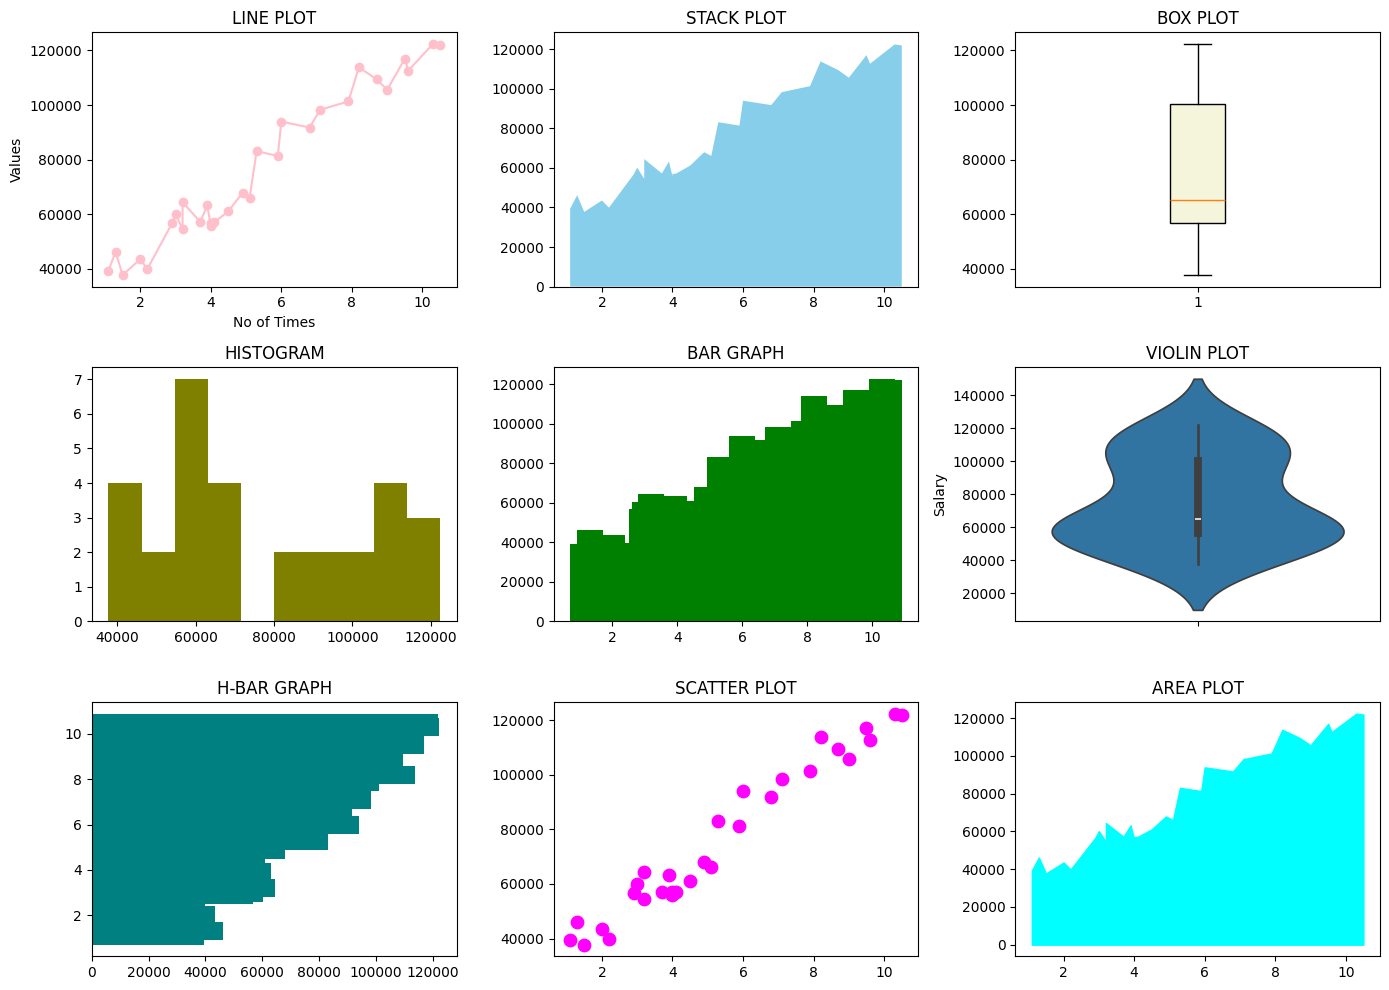

In [53]:
import matplotlib.pyplot as plt


x = df['YearsExperience']
y = df['Salary']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))

# 1. Line Plot
axes[0,0].plot(x, y, marker='o', color='pink')
axes[0,0].set_title("LINE PLOT")
axes[0,0].set_xlabel("No of Times")
axes[0,0].set_ylabel("Values")

# 2. Stack Plot
axes[0,1].stackplot(
    x,
    y,
    colors=['skyblue','lightgreen']
)
axes[0,1].set_title("STACK PLOT")

# 3. Box Plot
axes[0,2].boxplot(y, patch_artist=True, boxprops=dict(facecolor='beige'))
axes[0,2].set_title("BOX PLOT")

# 4. Histogram
axes[1,0].hist(y, color='olive')
axes[1,0].set_title("HISTOGRAM")

# 5. Bar Graph
axes[1,1].bar(x, y, color='green')
axes[1,1].set_title("BAR GRAPH")

# 6. Violin Plot
sns.violinplot(y=y, ax=axes[1,2])
axes[1,2].set_title("VIOLIN PLOT")

# 7. Horizontal Bar Graph
axes[2,0].barh(x, y, color='teal')
axes[2,0].set_title("H-BAR GRAPH")

# 8. Scatter Plot
axes[2,1].scatter(x, y, color='magenta', s=80)
axes[2,1].set_title("SCATTER PLOT")

# 9. Area Plot
axes[2,2].fill_between(x, y, color='cyan')
axes[2,2].set_title("AREA PLOT")

plt.tight_layout()
plt.show()